# ==============================================================================
# Notebook 2: Análise de Performance Técnica
# ==============================================================================
# Objetivo:
# 1. Carregar os dados pré-processados do arquivo 'all_experiment_data.pkl'.
# 2. Calcular métricas técnicas agregadas por modelo (latência média, mediana,
#    mín/máx, uso máximo de VRAM/RAM).
# 3. Gerar visualizações comparativas:
#    - Gráfico de barras para latência média/mediana.
#    - Gráfico de barras para uso máximo de VRAM/RAM.
#    - Violin plots para comparar a distribuição completa das latências.
# 4. Salvar a tabela de métricas e os gráficos gerados.
# ------------------------------------------------------------------------------
# Relevância para o TCC:
# - Avalia a "leveza" e eficiência dos modelos (viabilidade de execução local).
# - Fornece dados quantitativos para a Tabela 4.1 e gráficos de apoio.
# ---

In [1]:
# --- Imports ---
import pandas as pd
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Any
from IPython.display import display

In [2]:

# --- Configurações ---
# Diretório onde os dados processados foram salvos pelo Notebook 01
INPUT_DATA_DIR = Path("processed_data")
PROCESSED_DATA_FILE = INPUT_DATA_DIR / "all_experiment_data.pkl"

# Diretório para salvar os resultados desta análise (gráficos, tabelas)
OUTPUT_RESULTS_DIR = Path("results")
OUTPUT_RESULTS_DIR.mkdir(exist_ok=True) # Cria o diretório se não existir

print(f"Carregando dados processados de: {PROCESSED_DATA_FILE.absolute()}")
print(f"Salvando resultados em: {OUTPUT_RESULTS_DIR.absolute()}")

Carregando dados processados de: /Users/giossaurus/Developer/leia_tcc/notebooks/modelos_testes/processed_data/all_experiment_data.pkl
Salvando resultados em: /Users/giossaurus/Developer/leia_tcc/notebooks/modelos_testes/results


In [3]:
# ==============================================================================
# 1. Carregar Dados Processados
# ==============================================================================

all_data: Dict[str, pd.DataFrame] = {} # Inicializa como dicionário vazio

try:
    with open(PROCESSED_DATA_FILE, 'rb') as f:
        all_data = pickle.load(f)
    print(f"\n✅ Dados processados carregados com sucesso para {len(all_data)} modelos.")
    if all_data:
        print("   Modelos carregados:", list(all_data.keys()))
        # Mostra informações de um dos dataframes como exemplo
        example_model = list(all_data.keys())[0]
        print(f"\n   Exemplo de informações para {example_model}:")
        all_data[example_model].info()
    else:
        print("   ⚠️ O arquivo .pkl estava vazio.")

except FileNotFoundError:
    print(f"\n❌ ERRO: Arquivo '{PROCESSED_DATA_FILE.absolute()}' não encontrado.")
    print("   Certifique-se de que o Notebook 01 foi executado com sucesso primeiro.")
except Exception as e:
    print(f"\n❌ ERRO ao carregar o arquivo .pkl: {e}")


✅ Dados processados carregados com sucesso para 3 modelos.
   Modelos carregados: ['Qwen_Qwen2.5-7B-Instruct', 'google_gemma-2-2b-it', 'mistralai_Mistral-7B-Instruct-v0.2']

   Exemplo de informações para Qwen_Qwen2.5-7B-Instruct:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   turn_number         29 non-null     int64  
 1   timestamp           29 non-null     object 
 2   experiment_name     29 non-null     object 
 3   model_name          29 non-null     object 
 4   user_input          29 non-null     object 
 5   agent_response      29 non-null     object 
 6   session_id          29 non-null     object 
 7   condensed_question  29 non-null     object 
 8   nlu_label           29 non-null     object 
 9   nlu_confidence      29 non-null     float64
 10  agent_trace         29 non-null     object 
 11  response            29 

In [4]:
# ==============================================================================
# 2. Calcular Métricas Técnicas Agregadas
# ==============================================================================
# Descrição: Calcula estatísticas resumo (média, mediana, min, max) para
#            latência e uso de memória para cada modelo.

def compute_technical_metrics(data: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Calcula métricas técnicas agregadas por modelo."""
    metrics = []

    if not data:
        print("\n⚠️ Nenhum dado carregado para calcular métricas técnicas.")
        return pd.DataFrame() # Retorna DataFrame vazio

    print("\nCalculando métricas técnicas agregadas...")
    for model_name, df in data.items():
        if df.empty or 'latency_ms' not in df.columns:
             print(f"  ⚠️ DataFrame vazio ou sem 'latency_ms' para {model_name}. Pulando.")
             continue

        metrics.append({
            "Modelo": model_name,
            "Latência Média (ms)": df['latency_ms'].mean(),
            "Latência Mediana (ms)": df['latency_ms'].median(), # Mediana é mais robusta
            "Latência Mín (ms)": df['latency_ms'].min(),
            "Latência Máx (ms)": df['latency_ms'].max(),
            # Usa .get() para segurança caso a coluna não exista (preenchida no NB 01)
            "VRAM Máxima (MB)": df.get('vram_used_mb', pd.Series([0.0])).max(),
            "VRAM Média (MB)": df.get('vram_used_mb', pd.Series([0.0])).mean(),
            "RAM Máxima (MB)": df.get('ram_used_mb', pd.Series([0.0])).max(),
            "Total de Turnos": len(df),
        })

    if not metrics:
        print("  ⚠️ Nenhuma métrica pôde ser calculada.")
        return pd.DataFrame()

    print("  ✓ Métricas calculadas.")
    return pd.DataFrame(metrics).round(2)

# --- Execução do Cálculo e Exibição da Tabela ---
technical_metrics_summary = compute_technical_metrics(all_data)

print("\n" + "="*100)
print("TABELA: RESUMO DA PERFORMANCE TÉCNICA")
print("="*100)
if not technical_metrics_summary.empty:
    display(technical_metrics_summary)
    # Salvar a tabela
    summary_table_path = OUTPUT_RESULTS_DIR / "technical_metrics_summary.csv"
    technical_metrics_summary.to_csv(summary_table_path, index=False)
    print(f"\n✓ Tabela de resumo técnico exportada para: {summary_table_path}")
else:
    print("   Nenhuma métrica técnica para exibir ou exportar.")


Calculando métricas técnicas agregadas...
  ✓ Métricas calculadas.

TABELA: RESUMO DA PERFORMANCE TÉCNICA


,Modelo,Latência Média (ms),Latência Mediana (ms),Latência Mín (ms),Latência Máx (ms),VRAM Máxima (MB),VRAM Média (MB),RAM Máxima (MB),Total de Turnos
0,Qwen_Qwen2.5-7B-Instruct,124996.76,109935.30,13439.72,330123.36,0.0,0.0,22430.83,29
1,google_gemma-2-2b-it,22043.28,17119.79,2376.18,116975.44,0.0,0.0,19605.97,25
2,mistralai_Mistral-7B-Instruct-v0.2,46174.75,41065.34,10247.28,135211.72,0.0,0.0,23645.94,29



✓ Tabela de resumo técnico exportada para: results/technical_metrics_summary.csv



GRÁFICOS: COMPARAÇÃO DA PERFORMANCE TÉCNICA

✓ Gráfico de latência mediana salvo em: results/latency_median_comparison.png


/var/folders/k4/x1x0j4qs0svb48fpvhhvkmbh0000gn/T/ipykernel_10761/2557159768.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tech_sorted_median, x='Latência Mediana (ms)', y='Modelo', palette='viridis', orient='h')


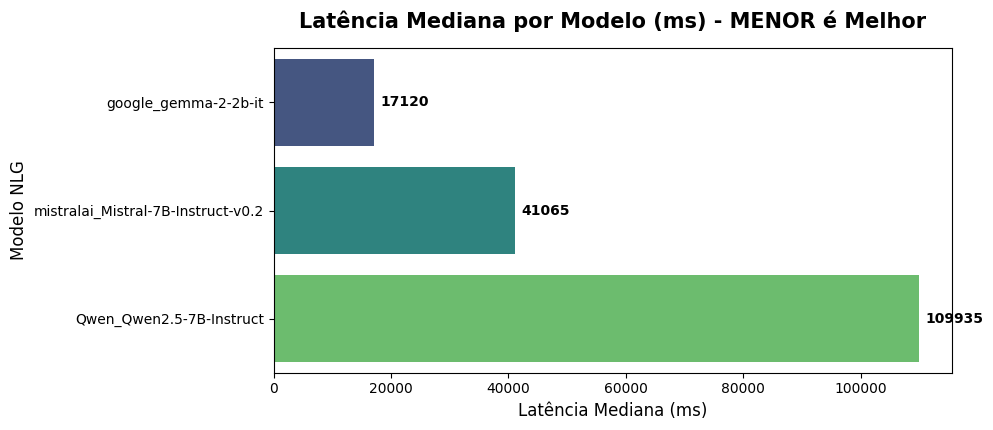

/var/folders/k4/x1x0j4qs0svb48fpvhhvkmbh0000gn/T/ipykernel_10761/2557159768.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=latency_data_raw, x='latency_ms', y='model_name', palette='Set2',



✓ Gráfico de distribuição de latência (violin) salvo em: results/latency_distribution_violin.png


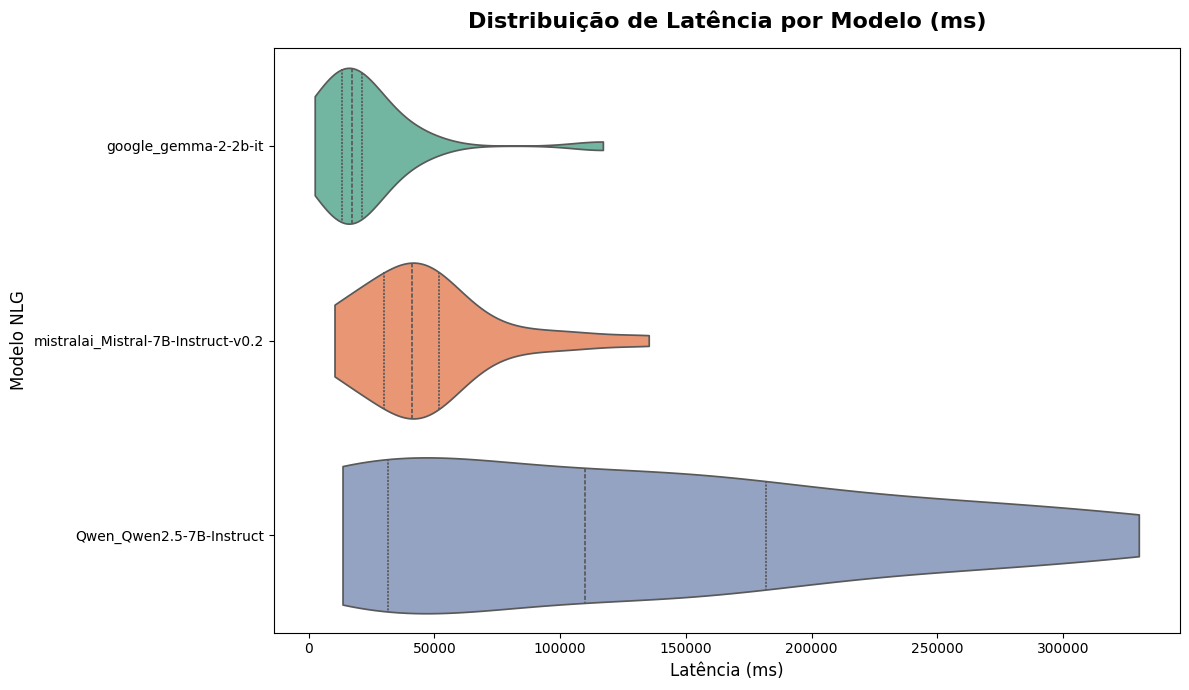

/var/folders/k4/x1x0j4qs0svb48fpvhhvkmbh0000gn/T/ipykernel_10761/2557159768.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tech_sorted_ram, x='RAM Máxima (MB)', y='Modelo', palette='mako', orient='h')



   INFO: Dados de VRAM não disponíveis ou todos zero. Gráfico de VRAM não gerado.

✓ Gráfico de RAM máxima salvo em: results/ram_max_comparison.png


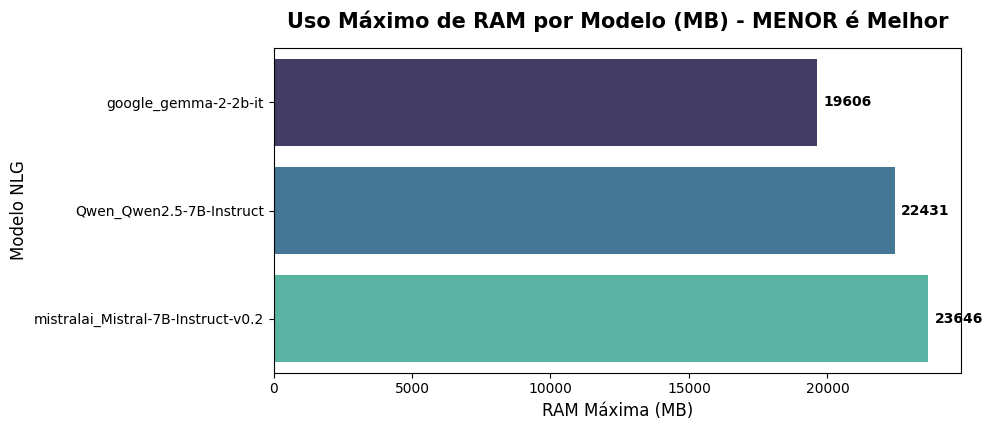

In [5]:
# ==============================================================================
# 3. Visualizações da Performance Técnica
# ==============================================================================
# Descrição: Gera gráficos para comparar visualmente a latência e o uso de
#            memória entre os diferentes modelos testados.

print("\n" + "="*100)
print("GRÁFICOS: COMPARAÇÃO DA PERFORMANCE TÉCNICA")
print("="*100)

if not technical_metrics_summary.empty:

    # --- Gráfico 1: Latência Mediana (Bar Chart Horizontal) ---
    # Usando mediana por ser mais robusta a outliers que a média
    plt.figure(figsize=(10, len(technical_metrics_summary) * 0.8 + 2)) # Ajusta altura ao num de modelos
    tech_sorted_median = technical_metrics_summary.sort_values('Latência Mediana (ms)', ascending=True)
    sns.barplot(data=tech_sorted_median, x='Latência Mediana (ms)', y='Modelo', palette='viridis', orient='h')
    plt.title('Latência Mediana por Modelo (ms) - MENOR é Melhor', fontsize=15, fontweight='bold', pad=15)
    plt.xlabel('Latência Mediana (ms)', fontsize=12)
    plt.ylabel('Modelo NLG', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    # Adicionar valores nas barras
    for index, value in enumerate(tech_sorted_median['Latência Mediana (ms)']):
        plt.text(value + tech_sorted_median['Latência Mediana (ms)'].max()*0.01, # Pequeno offset
                 index, f'{value:.0f}', va='center', fontsize=10, fontweight='bold')
    plt.tight_layout()
    fig_path = OUTPUT_RESULTS_DIR / "latency_median_comparison.png"
    plt.savefig(fig_path)
    print(f"\n✓ Gráfico de latência mediana salvo em: {fig_path}")
    plt.show()

    # --- Gráfico 2: Distribuição de Latência (Violin Plot) ---
    # Ideal para ver a forma da distribuição e comparar medianas/quartis
    if all_data: # Verifica se 'all_data' (dados brutos) não está vazio
        latency_data_raw = pd.concat(
            [df[['model_name', 'latency_ms']] for df in all_data.values() if not df.empty and 'latency_ms' in df.columns],
            ignore_index=True
        )
        if not latency_data_raw.empty:
            plt.figure(figsize=(12, 7))
            # Ordena modelos pela latência mediana para melhor visualização no violin plot
            order = tech_sorted_median['Modelo'].tolist()
            sns.violinplot(data=latency_data_raw, x='latency_ms', y='model_name', palette='Set2',
                           orient='h', order=order, inner='quartile', cut=0) # inner='quartile' mostra quartis
            plt.title('Distribuição de Latência por Modelo (ms)', fontsize=16, fontweight='bold', pad=15)
            plt.xlabel('Latência (ms)', fontsize=12)
            plt.ylabel('Modelo NLG', fontsize=12)
            plt.xticks(fontsize=10)
            plt.yticks(fontsize=10)
            # Considerar escala log se as caudas forem muito longas
            # plt.xscale('log')
            plt.tight_layout()
            fig_path = OUTPUT_RESULTS_DIR / "latency_distribution_violin.png"
            plt.savefig(fig_path)
            print(f"\n✓ Gráfico de distribuição de latência (violin) salvo em: {fig_path}")
            plt.show()
        else:
            print("   ⚠️ Não há dados brutos de latência para gerar o Violin Plot.")

    # --- Gráfico 3: Uso Máximo de VRAM (Bar Chart Horizontal) ---
    # Somente se houver dados de VRAM > 0
    if 'VRAM Máxima (MB)' in technical_metrics_summary.columns and technical_metrics_summary['VRAM Máxima (MB)'].sum() > 0:
        plt.figure(figsize=(10, len(technical_metrics_summary) * 0.8 + 2))
        tech_sorted_vram = technical_metrics_summary.sort_values('VRAM Máxima (MB)', ascending=True)
        sns.barplot(data=tech_sorted_vram, x='VRAM Máxima (MB)', y='Modelo', palette='rocket', orient='h')
        plt.title('Uso Máximo de VRAM por Modelo (MB) - MENOR é Melhor', fontsize=15, fontweight='bold', pad=15)
        plt.xlabel('VRAM Máxima (MB)', fontsize=12)
        plt.ylabel('Modelo NLG', fontsize=12)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
        # Adicionar valores nas barras
        for index, value in enumerate(tech_sorted_vram['VRAM Máxima (MB)']):
             if value > 0: # Só adiciona texto se for maior que 0
                 plt.text(value + tech_sorted_vram['VRAM Máxima (MB)'].max()*0.01,
                         index, f'{value:.0f}', va='center', fontsize=10, fontweight='bold')
        plt.tight_layout()
        fig_path = OUTPUT_RESULTS_DIR / "vram_max_comparison.png"
        plt.savefig(fig_path)
        print(f"\n✓ Gráfico de VRAM máxima salvo em: {fig_path}")
        plt.show()
    else:
        print("\n   INFO: Dados de VRAM não disponíveis ou todos zero. Gráfico de VRAM não gerado.")

    # --- Gráfico 4: Uso Máximo de RAM (Bar Chart Horizontal) ---
    # Similar ao de VRAM, mas para RAM do sistema
    if 'RAM Máxima (MB)' in technical_metrics_summary.columns and technical_metrics_summary['RAM Máxima (MB)'].sum() > 0:
        plt.figure(figsize=(10, len(technical_metrics_summary) * 0.8 + 2))
        tech_sorted_ram = technical_metrics_summary.sort_values('RAM Máxima (MB)', ascending=True)
        sns.barplot(data=tech_sorted_ram, x='RAM Máxima (MB)', y='Modelo', palette='mako', orient='h')
        plt.title('Uso Máximo de RAM por Modelo (MB) - MENOR é Melhor', fontsize=15, fontweight='bold', pad=15)
        plt.xlabel('RAM Máxima (MB)', fontsize=12)
        plt.ylabel('Modelo NLG', fontsize=12)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
        # Adicionar valores nas barras
        for index, value in enumerate(tech_sorted_ram['RAM Máxima (MB)']):
             if value > 0:
                 plt.text(value + tech_sorted_ram['RAM Máxima (MB)'].max()*0.01,
                         index, f'{value:.0f}', va='center', fontsize=10, fontweight='bold')
        plt.tight_layout()
        fig_path = OUTPUT_RESULTS_DIR / "ram_max_comparison.png"
        plt.savefig(fig_path)
        print(f"\n✓ Gráfico de RAM máxima salvo em: {fig_path}")
        plt.show()
    else:
        print("\n   INFO: Dados de RAM não disponíveis ou todos zero. Gráfico de RAM não gerado.")


else:
    print("\n   Nenhuma métrica técnica foi calculada, gráficos não podem ser gerados.")

In [6]:
# ==============================================================================
# 4. Insights Preliminares (Performance Técnica)
# ==============================================================================
print("\n" + "="*100)
print("INSIGHTS PRELIMINARES (PERFORMANCE TÉCNICA)")
print("="*100)
print("\nCom base nos resultados acima (preencher manualmente após análise):")
print("- Modelo(s) com menor latência mediana (mais rápidos): [...]")
print("- Modelo(s) com maior consistência na latência (distribuição mais compacta no violin plot): [...]")
print("- Modelo(s) com maior latência ou variabilidade (possíveis gargalos): [...]")
print("- Modelo(s) com menor uso de VRAM (mais 'leves' em GPU, se aplicável): [...]")
print("- Modelo(s) com menor uso de RAM (mais 'leves' em CPU/Memória): [...]")
print("- Trade-off: Qual(is) modelo(s) oferece(m) um bom equilíbrio entre velocidade e uso de recursos?")
print("\n(Estes insights ajudarão a preencher a Tabela 4.1 e a discussão no TCC)")


print("\n--- Fim do Notebook 02 ---")

# Nota: As análises e visualizações focadas na performance técnica estão concluídas.
# O próximo notebook (`03_qualitative_analysis_guardrails.ipynb`) carregará
# novamente o arquivo `all_experiment_data.pkl` para focar na análise
# da aderência pedagógica (guardrails).


INSIGHTS PRELIMINARES (PERFORMANCE TÉCNICA)

Com base nos resultados acima (preencher manualmente após análise):
- Modelo(s) com menor latência mediana (mais rápidos): [...]
- Modelo(s) com maior consistência na latência (distribuição mais compacta no violin plot): [...]
- Modelo(s) com maior latência ou variabilidade (possíveis gargalos): [...]
- Modelo(s) com menor uso de VRAM (mais 'leves' em GPU, se aplicável): [...]
- Modelo(s) com menor uso de RAM (mais 'leves' em CPU/Memória): [...]
- Trade-off: Qual(is) modelo(s) oferece(m) um bom equilíbrio entre velocidade e uso de recursos?

(Estes insights ajudarão a preencher a Tabela 4.1 e a discussão no TCC)

--- Fim do Notebook 02 ---
